# TerraTech — Predictive Analytics for Land Acquisition Delays

**Problem:** Land acquisition is the single largest cause of schedule slippage in
Indian infrastructure projects. Delays are currently detected *after* they occur,
through periodic review meetings.

**Objective:** Given the measurable state of a land-acquisition project, estimate
the probability that it will be delayed, and identify which factors are driving
that risk, early enough for corrective administrative action.

**Prediction target:** `delayed` — binary (1 = delayed, 0 = on schedule).

**Task type:** Supervised binary classification on structured tabular data.

## Data honesty statement

We do not have authorized case-level government land-acquisition data.
This notebook generates **synthetic, historical-style data** using a documented
statistical process. The relationships encoded in the generator are drawn from
domain reasoning about the LARR Act process, not from real case records.

Therefore:
- No metric in this notebook is a claim about real-world accuracy.
- All metrics reported are computed on a held-out test split of the synthetic data.
- The pipeline, not the accuracy number, is the contribution of this prototype.
- With authorized historical data, the same pipeline is retrained unchanged.

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from xgboost import XGBClassifier
import shap
import joblib

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths are relative to the notebook/ folder, so step up one level
DATA_DIR = "../data"
MODEL_DIR = "../models"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Libraries loaded.")
print("numpy", np.__version__, "| pandas", pd.__version__, "| shap", shap.__version__)

Libraries loaded.
numpy 1.26.4 | pandas 2.2.2 | shap 0.46.0


## Synthetic dataset generation

Each record is generated in three steps:

1. **Sample project characteristics** — type, land area, affected families, and
   the completion percentage of each acquisition stage, from distributions chosen
   to resemble plausible field conditions (skewed, bounded, correlated).

2. **Compute a latent risk score** — a weighted linear combination of the features
   on the log-odds scale, plus Gaussian noise representing everything we did not
   measure (local politics, monsoon, court calendars, officer turnover).

3. **Draw the label** — convert the latent score to a probability with the logistic
   function and sample `delayed` from a Bernoulli distribution.

Step 3 is what keeps the problem honest. The label is *probabilistic*, not a
deterministic function of the features, so a perfect model is impossible and the
reported metrics stay in a realistic range.

In [4]:
N_RECORDS = 3500
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_TYPES = ["Highway", "Railway", "Irrigation", "Industrial Corridor", "Urban Infrastructure"]
TYPE_WEIGHTS  = [0.32, 0.20, 0.18, 0.15, 0.15]

# Baseline difficulty of each project category, on the log-odds scale
TYPE_EFFECT = {
    "Highway": 0.00,
    "Railway": 0.15,
    "Irrigation": 0.35,          # submergence + large R&R burden
    "Industrial Corridor": 0.20,
    "Urban Infrastructure": 0.30 # dense titles, higher dispute rate
}

project_type = rng.choice(PROJECT_TYPES, size=N_RECORDS, p=TYPE_WEIGHTS)

# --- Project scale -------------------------------------------------------
land_area = np.clip(rng.gamma(shape=2.2, scale=150, size=N_RECORDS), 8, 1600).round(1)

# Affected families scale with land area but density varies widely
density = rng.gamma(shape=3.0, scale=0.28, size=N_RECORDS)
affected_families = np.clip((land_area * density).round(), 5, 3000).astype(int)

# --- Stage completion percentages ---------------------------------------
documentation_completion = np.clip(rng.normal(72, 16, N_RECORDS), 10, 100).round(1)

# Compensation cannot realistically run far ahead of documentation
compensation_completion = np.clip(
    documentation_completion - rng.normal(8, 14, N_RECORDS), 5, 100
).round(1)

rr_completion = np.clip(rng.normal(63, 20, N_RECORDS), 0, 100).round(1)

# Possession follows R&R; it rarely leads it
possession_completion = np.clip(
    rr_completion - rng.normal(9, 15, N_RECORDS), 0, 100
).round(1)

# --- Friction indicators -------------------------------------------------
# Dispute count rises with the number of affected families
dispute_rate = 0.9 + affected_families / 420
legal_disputes = rng.poisson(lam=dispute_rate).clip(0, 40)

approval_delay_days = np.clip(rng.gamma(shape=1.9, scale=12, size=N_RECORDS), 0, 220).round(0)
stakeholder_response_days = np.clip(rng.gamma(shape=2.6, scale=3.1, size=N_RECORDS), 1, 60).round(0)
historical_delay_rate = np.clip(rng.normal(26, 11, N_RECORDS), 2, 78).round(1)

# --- Latent risk on the log-odds scale ----------------------------------
type_effect = np.array([TYPE_EFFECT[t] for t in project_type])

latent = (
    -2.40
    + 0.030 * (70 - documentation_completion)
    + 0.038 * (75 - compensation_completion)
    + 0.220 * legal_disputes
    + 0.020 * approval_delay_days
    + 0.030 * (65 - rr_completion)
    + 0.018 * (60 - possession_completion)
    + 0.045 * stakeholder_response_days
    + 0.045 * (historical_delay_rate - 25)
    + 0.0010 * (land_area - 300)
    + 0.0012 * (affected_families - 250)
    + type_effect
    + rng.normal(0, 1.2, N_RECORDS)          # unobserved real-world factors
)

delay_probability = 1 / (1 + np.exp(-latent))
delayed = rng.binomial(1, delay_probability)

# Optional severity column: months of slippage, only meaningful when delayed
severity = np.clip(rng.gamma(shape=2.0, scale=38, size=N_RECORDS) * (0.55 + 0.35 * latent.clip(0, 4)), 15, 900)
actual_delay_days = np.where(delayed == 1, severity.round(0), 0).astype(int)

df = pd.DataFrame({
    "project_type": project_type,
    "land_area": land_area,
    "affected_families": affected_families,
    "documentation_completion": documentation_completion,
    "compensation_completion": compensation_completion,
    "legal_disputes": legal_disputes,
    "approval_delay_days": approval_delay_days.astype(int),
    "rr_completion": rr_completion,
    "possession_completion": possession_completion,
    "stakeholder_response_days": stakeholder_response_days.astype(int),
    "historical_delay_rate": historical_delay_rate,
    "delayed": delayed,
    "actual_delay_days": actual_delay_days,
})

csv_path = os.path.join(DATA_DIR, "historical_projects.csv")
df.to_csv(csv_path, index=False)

print(f"Generated {len(df)} records -> {csv_path}")
print("Delayed share:", round(df['delayed'].mean() * 100, 2), "%")

Generated 3500 records -> ../data\historical_projects.csv
Delayed share: 42.54 %


In [5]:
print("Shape:", df.shape)
print("\n--- Column types ---")
print(df.dtypes)
print("\n--- First 5 records ---")
display(df.head())
print("\n--- Numeric summary ---")
display(df.describe().T.round(2))

Shape: (3500, 13)

--- Column types ---
project_type                  object
land_area                    float64
affected_families              int32
documentation_completion     float64
compensation_completion      float64
legal_disputes                 int64
approval_delay_days            int32
rr_completion                float64
possession_completion        float64
stakeholder_response_days      int32
historical_delay_rate        float64
delayed                        int64
actual_delay_days              int32
dtype: object

--- First 5 records ---


,project_type,land_area,affected_families,documentation_completion,compensation_completion,legal_disputes,approval_delay_days,rr_completion,possession_completion,stakeholder_response_days,historical_delay_rate,delayed,actual_delay_days
0,Industrial Corridor,308.9,347,91.4,84.0,0,30,46.8,39.1,10,12.7,0,0
1,Railway,281.6,208,86.7,78.5,1,28,65.4,56.9,17,31.4,0,0
2,Urban Infrastructure,559.7,491,69.6,87.8,0,3,67.2,78.7,7,7.5,0,0
3,Irrigation,1343.5,862,68.9,70.9,5,27,48.8,34.5,12,12.0,1,114
4,Highway,365.5,459,67.2,60.2,2,53,52.6,35.3,11,18.2,0,0



--- Numeric summary ---


,count,mean,std,min,25%,50%,75%,max
land_area,3500.0,330.08,219.45,8.0,169.98,281.35,439.92,1600.0
affected_families,3500.0,279.84,274.01,5.0,101.00,195.00,364.00,2867.0
documentation_completion,3500.0,72.48,15.49,12.8,61.60,72.70,83.70,100.0
compensation_completion,3500.0,63.91,20.15,5.0,50.00,64.60,78.80,100.0
legal_disputes,3500.0,1.57,1.40,0.0,1.00,1.00,2.00,10.0
approval_delay_days,3500.0,22.48,15.97,0.0,11.00,19.00,31.00,157.0
rr_completion,3500.0,63.43,19.58,0.0,50.00,64.10,77.20,100.0
possession_completion,3500.0,54.45,23.67,0.0,38.18,54.70,71.60,100.0
stakeholder_response_days,3500.0,7.99,4.86,1.0,4.00,7.00,11.00,37.0
historical_delay_rate,3500.0,25.92,10.79,2.0,18.30,25.90,33.40,72.0


In [6]:
print("--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Class balance ---")
print(df["delayed"].value_counts())
print(df["delayed"].value_counts(normalize=True).round(4))

print("\n--- Project type distribution ---")
print(df["project_type"].value_counts())

# Range assertions: these must all hold, or the generator has a bug
pct_cols = ["documentation_completion", "compensation_completion",
            "rr_completion", "possession_completion", "historical_delay_rate"]
for c in pct_cols:
    assert df[c].between(0, 100).all(), f"{c} out of range"
assert (df["legal_disputes"] >= 0).all()
assert df["delayed"].isin([0, 1]).all()
print("\nAll range checks passed.")

--- Missing values per column ---
project_type                 0
land_area                    0
affected_families            0
documentation_completion     0
compensation_completion      0
legal_disputes               0
approval_delay_days          0
rr_completion                0
possession_completion        0
stakeholder_response_days    0
historical_delay_rate        0
delayed                      0
actual_delay_days            0
dtype: int64

--- Duplicate rows ---
0

--- Class balance ---
delayed
0    2011
1    1489
Name: count, dtype: int64
delayed
0    0.5746
1    0.4254
Name: proportion, dtype: float64

--- Project type distribution ---
project_type
Highway                 1135
Railway                  695
Irrigation               619
Urban Infrastructure     535
Industrial Corridor      516
Name: count, dtype: int64

All range checks passed.


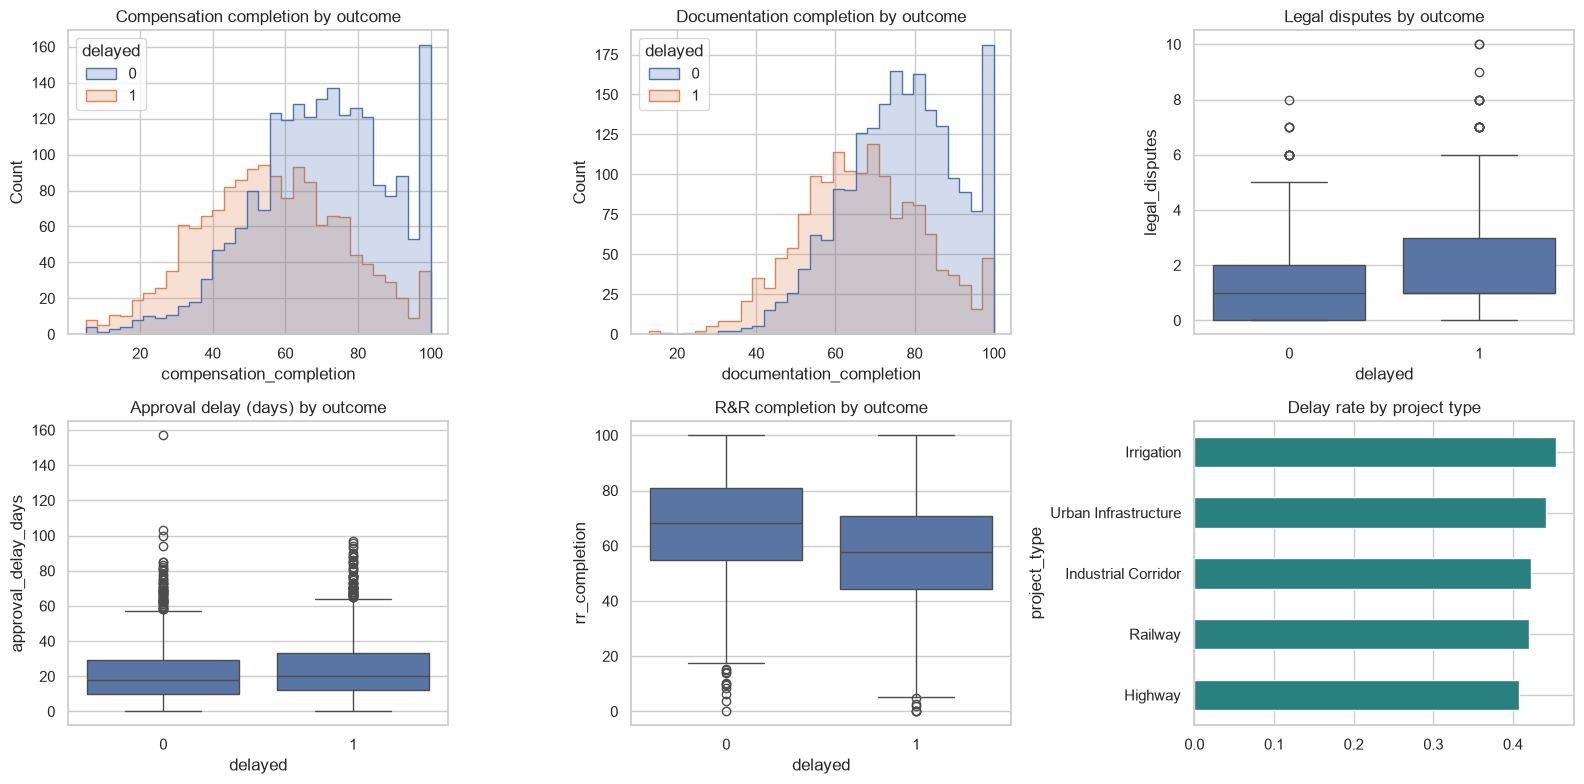


--- Correlation of each feature with the target ---
actual_delay_days            0.651
affected_families            0.171
land_area                    0.141
historical_delay_rate        0.128
legal_disputes               0.121
approval_delay_days          0.097
stakeholder_response_days    0.075
rr_completion               -0.260
possession_completion       -0.268
documentation_completion    -0.318
compensation_completion     -0.337
Name: delayed, dtype: float64


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(data=df, x="compensation_completion", hue="delayed",
             bins=30, ax=axes[0, 0], element="step")
axes[0, 0].set_title("Compensation completion by outcome")

sns.histplot(data=df, x="documentation_completion", hue="delayed",
             bins=30, ax=axes[0, 1], element="step")
axes[0, 1].set_title("Documentation completion by outcome")

sns.boxplot(data=df, x="delayed", y="legal_disputes", ax=axes[0, 2])
axes[0, 2].set_title("Legal disputes by outcome")

sns.boxplot(data=df, x="delayed", y="approval_delay_days", ax=axes[1, 0])
axes[1, 0].set_title("Approval delay (days) by outcome")

sns.boxplot(data=df, x="delayed", y="rr_completion", ax=axes[1, 1])
axes[1, 1].set_title("R&R completion by outcome")

delay_by_type = df.groupby("project_type")["delayed"].mean().sort_values()
delay_by_type.plot(kind="barh", ax=axes[1, 2], color="#2a7f7f")
axes[1, 2].set_title("Delay rate by project type")

plt.tight_layout()
plt.show()

print("\n--- Correlation of each feature with the target ---")
num_df = df.drop(columns=["project_type"])
print(num_df.corr(numeric_only=True)["delayed"].drop("delayed").sort_values(ascending=False).round(3))

In [8]:
FEATURES = [
    "project_type",
    "land_area",
    "affected_families",
    "documentation_completion",
    "compensation_completion",
    "legal_disputes",
    "approval_delay_days",
    "rr_completion",
    "possession_completion",
    "stakeholder_response_days",
    "historical_delay_rate",
]
TARGET = "delayed"

CATEGORICAL = ["project_type"]
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]

X_raw = df[FEATURES].copy()
y = df[TARGET].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
        ("num", "passthrough", NUMERIC),
    ],
    remainder="drop",
)

X = preprocessor.fit_transform(X_raw)
feature_names = list(preprocessor.get_feature_names_out())
feature_names = [n.replace("cat__", "").replace("num__", "") for n in feature_names]

print("Design matrix shape:", X.shape)
print("Encoded feature names:")
for i, n in enumerate(feature_names):
    print(f"  {i:2d}  {n}")

Design matrix shape: (3500, 15)
Encoded feature names:
   0  project_type_Highway
   1  project_type_Industrial Corridor
   2  project_type_Irrigation
   3  project_type_Railway
   4  project_type_Urban Infrastructure
   5  land_area
   6  affected_families
   7  documentation_completion
   8  compensation_completion
   9  legal_disputes
  10  approval_delay_days
  11  rr_completion
  12  possession_completion
  13  stakeholder_response_days
  14  historical_delay_rate


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train delayed share:", round(y_train.mean(), 4))
print("Test  delayed share:", round(y_test.mean(), 4))

Train: (2800, 15) | Test: (700, 15)
Train delayed share: 0.4254
Test  delayed share: 0.4257


In [10]:
model = XGBClassifier(
    n_estimators=350,
    max_depth=4,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print("Train ROC-AUC:", round(train_auc, 4))
print("Test  ROC-AUC:", round(test_auc, 4))
print("Gap (overfitting indicator):", round(train_auc - test_auc, 4))

Train ROC-AUC: 0.9475
Test  ROC-AUC: 0.7835
Gap (overfitting indicator): 0.164


--- Test-set metrics (threshold = 0.50) ---
accuracy  : 0.7114
precision : 0.6667
recall    : 0.6443
f1        : 0.6553
roc_auc   : 0.7835

--- Confusion matrix ---
                pred on-time  pred delayed
actual on-time           306            96
actual delayed           106           192

--- Classification report ---
              precision    recall  f1-score   support

     on-time      0.743     0.761     0.752       402
     delayed      0.667     0.644     0.655       298

    accuracy                          0.711       700
   macro avg      0.705     0.703     0.704       700
weighted avg      0.710     0.711     0.711       700



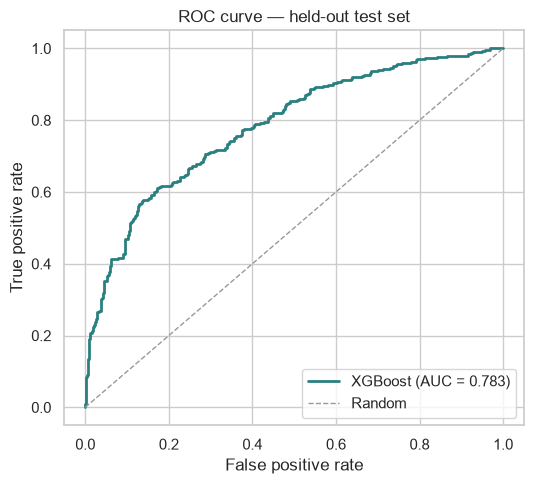

In [11]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

metrics = {
    "accuracy":  accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall":    recall_score(y_test, y_pred),
    "f1":        f1_score(y_test, y_pred),
    "roc_auc":   roc_auc_score(y_test, y_pred_proba),
}

print("--- Test-set metrics (threshold = 0.50) ---")
for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\n--- Confusion matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm,
                   index=["actual on-time", "actual delayed"],
                   columns=["pred on-time", "pred delayed"]))

print("\n--- Classification report ---")
print(classification_report(y_test, y_pred, target_names=["on-time", "delayed"], digits=3))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, lw=2, color="#2a7f7f", label=f"XGBoost (AUC = {metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="#999", lw=1, label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve — held-out test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Note on the decision threshold

The 0.50 threshold above is the default, not a recommendation. In deployment the
threshold is a policy choice: lowering it raises recall (fewer missed delays) at
the cost of precision (more projects flagged for review). For an early-warning
system where a false alarm costs one review meeting and a miss costs months of
project time, a threshold below 0.50 is defensible.

The Streamlit dashboard therefore presents the **probability and risk band**
rather than a hard binary verdict.

,feature,gain
0,compensation_completion,0.1382
1,rr_completion,0.0910
2,possession_completion,0.0818
3,affected_families,0.0717
4,documentation_completion,0.0681
5,stakeholder_response_days,0.0624
6,historical_delay_rate,0.0583
7,legal_disputes,0.0579
8,project_type_Irrigation,0.0565
9,approval_delay_days,0.0549


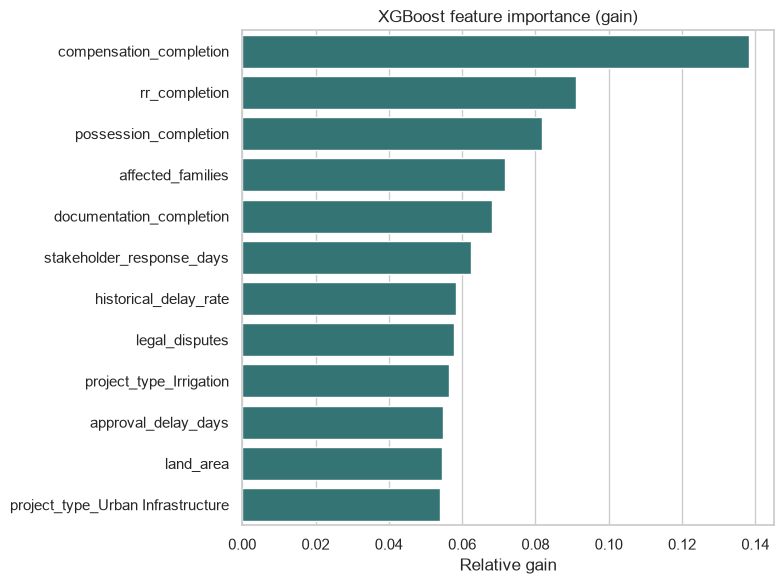

In [12]:
importance = (
    pd.DataFrame({"feature": feature_names, "gain": model.feature_importances_})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
display(importance.round(4))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance.head(12), y="feature", x="gain", color="#2a7f7f")
plt.title("XGBoost feature importance (gain)")
plt.xlabel("Relative gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [13]:
demo_project = {
    "project_id": "NH-47-024",
    "project_name": "NH-47 Four-Laning — Indore Section",
    "project_type": "Highway",
    "state": "Madhya Pradesh",
    "district": "Indore",
    "latitude": 22.7196,
    "longitude": 75.8577,
    "land_area": 482.0,
    "affected_families": 348,
    "documentation_completion": 78.0,
    "compensation_completion": 62.0,
    "legal_disputes": 8,
    "approval_delay_days": 21,
    "rr_completion": 48.0,
    "possession_completion": 35.0,
    "stakeholder_response_days": 9,
    "historical_delay_rate": 27.0,
    "data_note": "Prototype demo values. Not a real government record.",
}

demo_df = pd.DataFrame([{k: demo_project[k] for k in FEATURES}])
display(demo_df)

demo_X = preprocessor.transform(demo_df)
demo_proba = float(model.predict_proba(demo_X)[0, 1])

def risk_category(p):
    if p < 0.40:
        return "LOW"
    elif p < 0.70:
        return "MEDIUM"
    return "HIGH"

print(f"\nDelay probability : {demo_proba:.4f}  ({demo_proba*100:.1f}%)")
print(f"Risk score (0-100): {demo_proba*100:.1f}")
print(f"Risk category     : {risk_category(demo_proba)}")

json_path = os.path.join(DATA_DIR, "demo_project.json")
with open(json_path, "w") as f:
    json.dump(demo_project, f, indent=2)
print(f"\nSaved -> {json_path}")

,project_type,land_area,affected_families,documentation_completion,compensation_completion,legal_disputes,approval_delay_days,rr_completion,possession_completion,stakeholder_response_days,historical_delay_rate
0,Highway,482.0,348,78.0,62.0,8,21,48.0,35.0,9,27.0



Delay probability : 0.7291  (72.9%)
Risk score (0-100): 72.9
Risk category     : HIGH

Saved -> ../data\demo_project.json


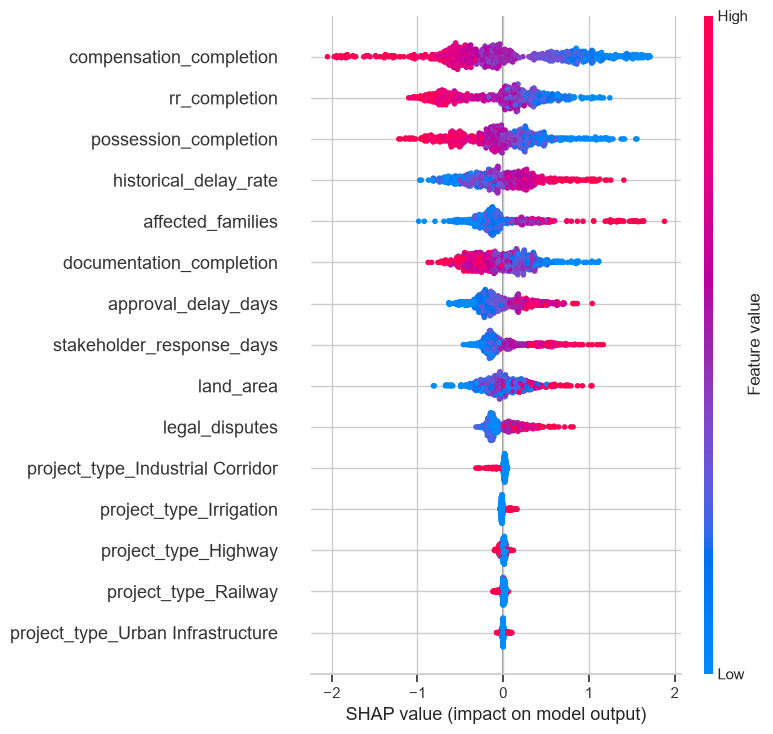

--- Top contributors for NH-47-024 (log-odds scale) ---


,feature,value,shap,abs_shap
0,legal_disputes,8.0,0.5526,0.5526
1,rr_completion,48.0,0.4230,0.4230
2,possession_completion,35.0,0.3596,0.3596
3,land_area,482.0,0.1204,0.1204
4,documentation_completion,78.0,-0.1104,0.1104
5,compensation_completion,62.0,0.0927,0.0927
6,approval_delay_days,21.0,-0.0678,0.0678
7,project_type_Highway,1.0,-0.0625,0.0625



Base value (log-odds)      : -0.3007
Sum of SHAP contributions  : 1.2905
Base + contributions       : 0.9898
Logistic of the above      : 0.7291
Model predict_proba        : 0.7291

--- Plain-language explanation ---
Predicted delay probability: 72.9% (HIGH risk).
Risk is increased mainly by:
  - legal_disputes (current value 8.0)
  - rr_completion (current value 48.0)
  - possession_completion (current value 35.0)
Risk is reduced by:
  - documentation_completion (current value 78.0)
  - approval_delay_days (current value 21.0)


In [14]:
explainer = shap.TreeExplainer(model)

# Global view on a sample of the test set
shap_values_test = explainer.shap_values(X_test)
shap.summary_plot(shap_values_test, X_test, feature_names=feature_names, show=True)

# Local view for the demo project
demo_shap = explainer.shap_values(demo_X)[0]
base_value = float(explainer.expected_value)

contrib = (
    pd.DataFrame({
        "feature": feature_names,
        "value": demo_X[0],
        "shap": demo_shap,
    })
    .assign(abs_shap=lambda d: d["shap"].abs())
    .sort_values("abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("--- Top contributors for NH-47-024 (log-odds scale) ---")
display(contrib.head(8).round(4))

print(f"\nBase value (log-odds)      : {base_value:.4f}")
print(f"Sum of SHAP contributions  : {demo_shap.sum():.4f}")
print(f"Base + contributions       : {base_value + demo_shap.sum():.4f}")
print(f"Logistic of the above      : {1/(1+np.exp(-(base_value + demo_shap.sum()))):.4f}")
print(f"Model predict_proba        : {demo_proba:.4f}")

# Plain-language explanation generated from the actual top contributors
top_up = contrib[contrib["shap"] > 0].head(3)
top_down = contrib[contrib["shap"] < 0].head(2)

print("\n--- Plain-language explanation ---")
print(f"Predicted delay probability: {demo_proba*100:.1f}% ({risk_category(demo_proba)} risk).")
print("Risk is increased mainly by:")
for _, r in top_up.iterrows():
    print(f"  - {r['feature']} (current value {r['value']:.1f})")
if len(top_down):
    print("Risk is reduced by:")
    for _, r in top_down.iterrows():
        print(f"  - {r['feature']} (current value {r['value']:.1f})")

In [15]:
model_path  = os.path.join(MODEL_DIR, "classifier.joblib")
prep_path   = os.path.join(MODEL_DIR, "preprocessing.joblib")
meta_path   = os.path.join(MODEL_DIR, "feature_metadata.joblib")

joblib.dump(model, model_path)
joblib.dump(preprocessor, prep_path)

metadata = {
    "features": FEATURES,
    "categorical": CATEGORICAL,
    "numeric": NUMERIC,
    "encoded_feature_names": feature_names,
    "project_types": PROJECT_TYPES,
    "target": TARGET,
    "random_seed": RANDOM_SEED,
    "n_training_records": int(len(df)),
    "risk_bands": {"LOW": [0.0, 0.40], "MEDIUM": [0.40, 0.70], "HIGH": [0.70, 1.0]},
    "test_metrics": {k: round(float(v), 4) for k, v in metrics.items()},
    "data_note": "Synthetic historical-style data. Metrics are from the held-out test split only.",
}
joblib.dump(metadata, meta_path)

print("Saved:")
for p in (model_path, prep_path, meta_path):
    print(f"  {p}  ({os.path.getsize(p)/1024:.1f} KB)")

# Reload check — this is what Streamlit will do
m2 = joblib.load(model_path)
p2 = joblib.load(prep_path)
check = float(m2.predict_proba(p2.transform(demo_df))[0, 1])
print(f"\nReload check — original {demo_proba:.6f} | reloaded {check:.6f}")
assert abs(check - demo_proba) < 1e-9, "Artifact mismatch"
print("Artifacts verified.")

Saved:
  ../models\classifier.joblib  (477.5 KB)
  ../models\preprocessing.joblib  (3.3 KB)
  ../models\feature_metadata.joblib  (1.1 KB)

Reload check — original 0.729052 | reloaded 0.729052
Artifacts verified.


## Conclusions

**What was built**
A binary classification pipeline that maps 11 land-acquisition project attributes
to a delay probability, with exact per-project SHAP attributions and saved
artifacts ready for the Streamlit decision-support layer.

**Pipeline**
synthetic generation → quality checks → EDA → one-hot encoding via a fitted
ColumnTransformer → stratified 80/20 split → XGBoost → test-set evaluation →
global gain importance → single-project prediction → local SHAP explanation →
joblib persistence.

**Results** — record the actual numbers from Cell 11 here.

**Honest limitations**
1. Data is synthetic. Metrics measure how well the model recovers a known
   generating process, not real administrative outcomes.
2. Features are a snapshot, not a time series. The model cannot yet express
   velocity ("compensation has not moved in six weeks").
3. `actual_delay_days` is a synthetic severity proxy.
4. Risk bands (LOW/MEDIUM/HIGH) are a product decision, not learned.
5. No external factors: litigation calendars, monsoon, elections, fund releases.

**Path to production**
Retrain the identical pipeline on authorized historical case data, add temporal
features, calibrate the probabilities, and validate against outcomes held out by
time rather than at random.

In [1]:
import sys
print(sys.executable)

d:\Terratech\.venv\Scripts\python.exe
